# Gravitational Lens CNN — Run & Verify

**Assumes these files are in the same folder as this notebook:**
```
config.py  dataset.py  model.py  train.py  predict.py  interface.py
data/lens_01.npy … data/nonlens_10.npy
checkpoints/final_weights.pth   ← only needed for Cells 6-8; run Cell 5 first
```

**Run order:** Cell 0 → restart kernel → Cell 1 onwards top to bottom.

## Cell 0 — Install dependencies
Run once, then **restart the kernel**.

In [5]:
import sys
!{sys.executable} -m pip install torch torchvision scikit-learn matplotlib tqdm astropy lenstronomy --quiet
print("Done — restart the kernel now (Kernel → Restart), then run from Cell 1.")

Done — restart the kernel now (Kernel → Restart), then run from Cell 1.


---
## Cell 1 — Verify all project files are present

In [1]:
import os, sys

required = [
    'config.py', 'dataset.py', 'model.py',
    'train.py', 'predict.py', 'interface.py',
]
data_files = [f'data/lens_{i:02d}.npy'    for i in range(1, 11)] + \
             [f'data/nonlens_{i:02d}.npy' for i in range(1, 11)]

all_ok = True
print("=== Project file check ===")
for f in required + data_files:
    exists = os.path.exists(f)
    print(f"  {'✓' if exists else '✗'} {f}")
    if not exists:
        all_ok = False

ckpt_exists = os.path.exists('checkpoints/final_weights.pth')
print(f"  {'✓' if ckpt_exists else '⚠ (run Cell 5 to train first)'} checkpoints/final_weights.pth")

print()
if all_ok:
    print("✓ All required files present. Continue to Cell 2.")
else:
    print("✗ Some files missing — make sure all .py files and data/ folder are uploaded.")

=== Project file check ===
  ✓ config.py
  ✓ dataset.py
  ✓ model.py
  ✓ train.py
  ✓ predict.py
  ✓ interface.py
  ✓ data/lens_01.npy
  ✓ data/lens_02.npy
  ✓ data/lens_03.npy
  ✓ data/lens_04.npy
  ✓ data/lens_05.npy
  ✓ data/lens_06.npy
  ✓ data/lens_07.npy
  ✓ data/lens_08.npy
  ✓ data/lens_09.npy
  ✓ data/lens_10.npy
  ✓ data/nonlens_01.npy
  ✓ data/nonlens_02.npy
  ✓ data/nonlens_03.npy
  ✓ data/nonlens_04.npy
  ✓ data/nonlens_05.npy
  ✓ data/nonlens_06.npy
  ✓ data/nonlens_07.npy
  ✓ data/nonlens_08.npy
  ✓ data/nonlens_09.npy
  ✓ data/nonlens_10.npy
  ✓ checkpoints/final_weights.pth

✓ All required files present. Continue to Cell 2.


---
## Cell 2 — Import everything and check the interface

In [3]:
import sys, os, warnings
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

sys.path.insert(0, '.')  # make sure local .py files are importable

import interface as iface

print("Interface exports:")
print(f"  TheModel      : {iface.TheModel}")
print(f"  the_trainer   : {iface.the_trainer}")
print(f"  the_predictor : {iface.the_predictor}")
print(f"  TheDataset    : {iface.TheDataset}")
print(f"  the_dataloader: {iface.the_dataloader}")
print(f"  the_batch_size: {iface.the_batch_size}")
print(f"  total_epochs  : {iface.total_epochs}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")

Interface exports:
  TheModel      : <class 'model.GravLensNet'>
  the_trainer   : <function train_model at 0x1380f0540>
  the_predictor : <function predict_lenses at 0x1380f0ae0>
  TheDataset    : <class 'dataset.LensDataset'>
  the_dataloader: <function get_dataloader at 0x1380f0f40>
  the_batch_size: 64
  total_epochs  : 30

Device: cpu


---
## Cell 3 — Visualise the 20 example data files
This is how you inspect `.npy` image files — open them with numpy and plot with matplotlib.

In [ ]:
def log_stretch(img):
    """Log-stretch + normalise to [0,1] — compresses the high dynamic range."""
    s = np.log1p(np.maximum(img, 0))
    return (s - s.min()) / (s.max() - s.min() + 1e-8)

fig, axes = plt.subplots(2, 10, figsize=(20, 4.5))
fig.patch.set_facecolor('#111')

for col in range(10):
    lens    = np.load(f'data/lens_{col+1:02d}.npy')
    nonlens = np.load(f'data/nonlens_{col+1:02d}.npy')

    axes[0, col].imshow(log_stretch(lens),    cmap='inferno', origin='lower')
    axes[0, col].set_title(f'lens_{col+1:02d}',    fontsize=7, color='#ff6b6b', pad=2)
    axes[0, col].axis('off')

    axes[1, col].imshow(log_stretch(nonlens), cmap='inferno', origin='lower')
    axes[1, col].set_title(f'nonlens_{col+1:02d}', fontsize=7, color='#74b9ff', pad=2)
    axes[1, col].axis('off')

axes[0,0].set_ylabel('LENSED', color='#ff6b6b', fontsize=10)
axes[1,0].set_ylabel('NON-LENSED', color='#74b9ff', fontsize=10)

plt.suptitle('Example images (log-stretched) — generated by lenstronomy\n'
             'Lensed: should show arc/ring structures  |  Non-lensed: smooth galaxy',
             fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

# Single image deep-dive
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
img = np.load('data/lens_01.npy')
axes[0].imshow(img,               cmap='gray',    origin='lower'); axes[0].set_title('Raw pixel values')
axes[1].imshow(log_stretch(img),  cmap='inferno', origin='lower'); axes[1].set_title('Log-stretched (as fed to model)')
axes[2].hist(img.flatten(), bins=50, color='steelblue')
axes[2].set_title('Pixel value distribution')
axes[2].set_xlabel('Flux')
for ax in axes[:2]: ax.axis('off')
plt.suptitle('lens_01.npy — deep inspection', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"lens_01.npy  →  shape={img.shape}  dtype={img.dtype}  min={img.min():.4f}  max={img.max():.4f}")

---
## Cell 4 — Generate dataset (skip if data/images.npy already exists)

Only run this if you haven't generated the training data yet.  
Start with `N = 200` to test end-to-end quickly. Use `N = 10_000` for the full run.

In [6]:
if os.path.exists('data/images.npy') and os.path.exists('data/labels.npy'):
    imgs = np.load('data/images.npy')
    lbls = np.load('data/labels.npy')
    print(f"data/images.npy already exists — shape={imgs.shape}  labels={lbls.shape}")
    print("Skipping generation. Delete data/images.npy to regenerate.")
else:
    print("Generating dataset — this takes a few minutes...")
    # Uses the same pipeline as generate_data.py
    N = 10000   # ← change to 10_000 for full project run
    !python3 generate_data.py --n {N}
    imgs = np.load('data/images.npy')
    lbls = np.load('data/labels.npy')
    print(f"\nGenerated: images={imgs.shape}  labels={lbls.shape}")

Generating dataset — this takes a few minutes...
=== Generating full training dataset (10000 images/class) ===
Unlensed: 100%|██████████████████████████| 10000/10000 [00:10<00:00, 935.87it/s]
Saved images.npy (20000, 64, 64)  labels.npy (20000,)

=== Saving 10 example images per class for data/ directory ===
Example unlensed: 100%|████████████████████████| 10/10 [00:00<00:00, 883.31it/s]
Done. Example images: lens_01.npy … lens_10.npy  nonlens_01.npy … nonlens_10.npy

Generated: images=(20000, 64, 64)  labels=(20000,)


---
## Cell 5 — Build dataloaders + train the model

Skip this cell if `checkpoints/final_weights.pth` is already uploaded (go to Cell 6).

In [7]:
from torch.optim import Adam
from tqdm.notebook import tqdm as nb_tqdm

# ── CONFIG — adjust as needed ──────────────────────────────────────────────
EPOCHS    = 10    # use 30 for full proposal run
LR        = 1e-4
PATIENCE  = 5
# ──────────────────────────────────────────────────────────────────────────

# Build dataloaders using the interface
train_loader, val_loader, test_loader = iface.the_dataloader()

bx, by = next(iter(train_loader))
print(f"Batch shape: images={tuple(bx.shape)}  labels={tuple(by.shape)}")
print(f"Label range: min={by.min()}  max={by.max()}\n")

# Build model
model     = iface.TheModel(pretrained=True).to(device)
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
loss_fn   = nn.BCEWithLogitsLoss()

# Train
print(f"Training for up to {EPOCHS} epochs...")
history = iface.the_trainer(
    model, EPOCHS, train_loader, loss_fn, optimizer,
    val_loader=val_loader, device=device, verbose=True
)

print(f"\nCheckpoint saved to: checkpoints/final_weights.pth")

[dataset] train=14000  val=3000  test=3000
Batch shape: images=(64, 3, 64, 64)  labels=(64,)
Label range: min=0  max=1

Training for up to 10 epochs...
Epoch 001/10  train loss=0.0280 acc=0.9904  val loss=0.0029 acc=0.9993 AUC=1.0000 ←
Epoch 002/10  train loss=0.0055 acc=0.9983  val loss=0.1514 acc=0.9633 AUC=0.9998
Epoch 003/10  train loss=0.0050 acc=0.9981  val loss=0.0005 acc=0.9997 AUC=1.0000 ←
Epoch 004/10  train loss=0.0021 acc=0.9994  val loss=0.0144 acc=0.9967 AUC=0.9999
Epoch 005/10  train loss=0.0023 acc=0.9994  val loss=0.0002 acc=1.0000 AUC=1.0000
Epoch 006/10  train loss=0.0014 acc=0.9997  val loss=0.0002 acc=1.0000 AUC=1.0000
Epoch 007/10  train loss=0.0010 acc=0.9997  val loss=0.0001 acc=1.0000 AUC=1.0000
Epoch 008/10  train loss=0.0003 acc=0.9999  val loss=0.0000 acc=1.0000 AUC=1.0000
Epoch 009/10  train loss=0.0001 acc=1.0000  val loss=0.0001 acc=1.0000 AUC=1.0000
Epoch 010/10  train loss=0.0003 acc=0.9999  val loss=0.0001 acc=1.0000 AUC=1.0000

Training complete. Best

### Training curves

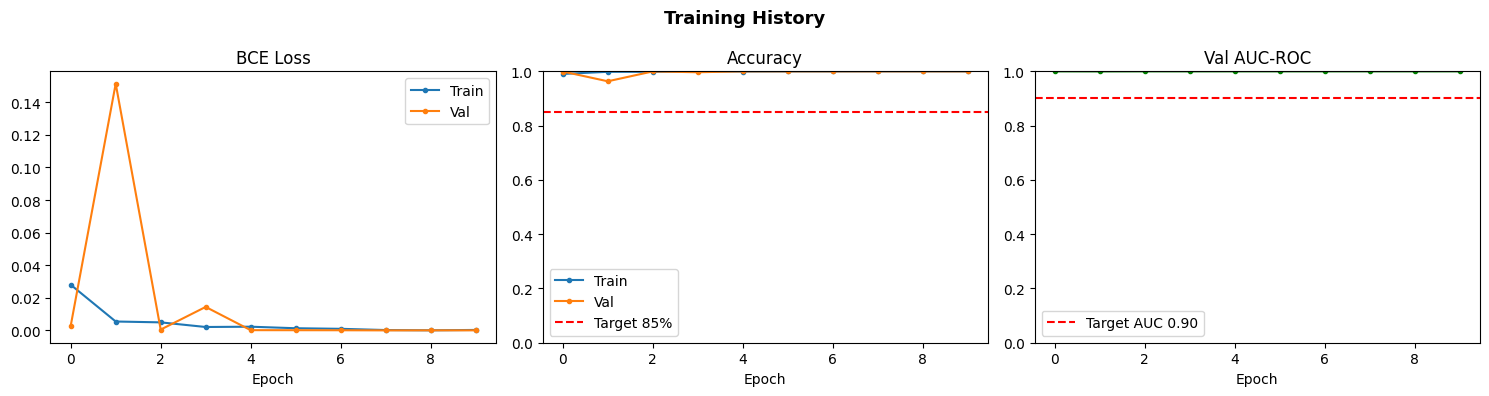

Healthy training: loss decreasing, AUC trending above 0.90 red line.


In [9]:
# Only run this after Cell 5
if 'history' not in dir():
    print("Run Cell 5 first to get training history.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(history['train_loss'], label='Train', marker='o', ms=3)
    axes[0].plot(history['val_loss'],   label='Val',   marker='o', ms=3)
    axes[0].set_title('BCE Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(history['train_acc'], label='Train', marker='o', ms=3)
    axes[1].plot(history['val_acc'],   label='Val',   marker='o', ms=3)
    axes[1].axhline(0.85, color='red', ls='--', label='Target 85%')
    axes[1].set_ylim(0, 1); axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].legend()

    axes[2].plot(history['val_auc'], color='green', marker='o', ms=3)
    axes[2].axhline(0.90, color='red', ls='--', label='Target AUC 0.90')
    axes[2].set_ylim(0, 1); axes[2].set_title('Val AUC-ROC')
    axes[2].set_xlabel('Epoch'); axes[2].legend()

    plt.suptitle('Training History', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    print("Healthy training: loss decreasing, AUC trending above 0.90 red line.")

---
## Cell 6 — Load trained weights + evaluate on test set

Loaded weights from checkpoints/final_weights.pth

═════════════════════════════════════════════
  TEST SET RESULTS
═════════════════════════════════════════════
  AUC-ROC   : 1.0000  ✓ PASS (≥0.90)
  Accuracy  : 1.0000  ✓ PASS (≥0.85)
  F1 Score  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
═════════════════════════════════════════════

              precision    recall  f1-score   support

    Non-Lens       1.00      1.00      1.00      1538
        Lens       1.00      1.00      1.00      1462

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



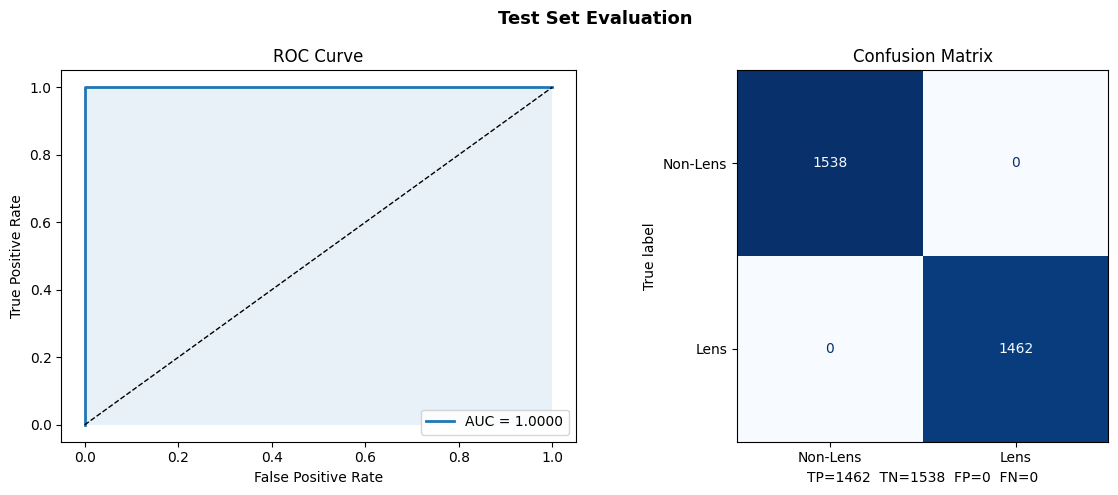

In [10]:
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import config

# Load the best checkpoint
if not os.path.exists(config.weights_path):
    raise FileNotFoundError(
        f"{config.weights_path} not found. Run Cell 5 first to train the model."
    )

# Make sure we have a test_loader (build if Cell 5 was skipped)
if 'test_loader' not in dir():
    train_loader, val_loader, test_loader = iface.the_dataloader()

model = iface.TheModel(pretrained=False).to(device)
model.load_state_dict(torch.load(config.weights_path, map_location=device))
model.eval()
print(f"Loaded weights from {config.weights_path}")

# Run inference on test set
all_probs, all_preds, all_true = [], [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs  = imgs.to(device)
        probs = torch.sigmoid(model(imgs)).view(-1).cpu()
        all_probs.extend(probs.tolist())
        all_preds.extend((probs > 0.5).long().tolist())
        all_true.extend(lbls.tolist())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_true  = np.array(all_true)

auc  = roc_auc_score(all_true, all_probs)
acc  = (all_preds == all_true).mean()
f1   = f1_score(all_true, all_preds)
prec = precision_score(all_true, all_preds)
rec  = recall_score(all_true, all_preds)

print("\n" + "═"*45)
print("  TEST SET RESULTS")
print("═"*45)
print(f"  AUC-ROC   : {auc:.4f}  {'✓ PASS (≥0.90)' if auc >= 0.90 else '✗ below target'}")
print(f"  Accuracy  : {acc:.4f}  {'✓ PASS (≥0.85)' if acc >= 0.85 else '✗ below target'}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print("═"*45)
print()
print(classification_report(all_true, all_preds, target_names=['Non-Lens','Lens']))

# ROC + Confusion matrix side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(all_true, all_probs)
ax1.plot(fpr, tpr, lw=2, label=f'AUC = {auc:.4f}')
ax1.plot([0,1],[0,1],'k--',lw=1)
ax1.fill_between(fpr, tpr, alpha=0.1)
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve'); ax1.legend(loc='lower right')

cm = confusion_matrix(all_true, all_preds)
ConfusionMatrixDisplay(cm, display_labels=['Non-Lens','Lens']).plot(
    ax=ax2, colorbar=False, cmap='Blues')
tn, fp, fn, tp = cm.ravel()
ax2.set_title('Confusion Matrix')
ax2.set_xlabel(f'TP={tp}  TN={tn}  FP={fp}  FN={fn}')

plt.suptitle('Test Set Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Cell 7 — Run predict_lenses() on the 20 example files
This is exactly what the grader will call via `the_predictor`.

In [11]:
lens_paths    = [f'data/lens_{i:02d}.npy'    for i in range(1, 11)]
nonlens_paths = [f'data/nonlens_{i:02d}.npy' for i in range(1, 11)]
all_paths     = lens_paths + nonlens_paths
ground_truth  = ['Lens']*10 + ['Non-Lens']*10

results = iface.the_predictor(all_paths)

correct = 0
print(f"{'File':<22}  {'GT':<10}  {'Predicted':<10}  {'Prob':>6}  Match")
print("-" * 62)
for r, gt in zip(results, ground_truth):
    fname = os.path.basename(r['path'])
    match = '✓' if r['prediction'] == gt else '✗'
    if r['prediction'] == gt: correct += 1
    print(f"{fname:<22}  {gt:<10}  {r['prediction']:<10}  {r['probability']:>6.4f}  {match}")

print("-" * 62)
score = correct / len(results)
print(f"\nResult: {correct}/{len(results)} correct  ({score*100:.1f}%)")
if   score >= 0.80: print("✓ PASS")
elif score >= 0.60: print("⚠ PARTIAL — try more training epochs")
else:               print("✗ FAIL — something is wrong")

File                    GT          Predicted     Prob  Match
--------------------------------------------------------------
lens_01.npy             Lens        Lens        1.0000  ✓
lens_02.npy             Lens        Lens        1.0000  ✓
lens_03.npy             Lens        Lens        0.9983  ✓
lens_04.npy             Lens        Lens        0.9999  ✓
lens_05.npy             Lens        Lens        1.0000  ✓
lens_06.npy             Lens        Lens        1.0000  ✓
lens_07.npy             Lens        Lens        0.9999  ✓
lens_08.npy             Lens        Lens        1.0000  ✓
lens_09.npy             Lens        Lens        1.0000  ✓
lens_10.npy             Lens        Lens        1.0000  ✓
nonlens_01.npy          Non-Lens    Non-Lens    0.0001  ✓
nonlens_02.npy          Non-Lens    Non-Lens    0.0000  ✓
nonlens_03.npy          Non-Lens    Non-Lens    0.0001  ✓
nonlens_04.npy          Non-Lens    Non-Lens    0.0000  ✓
nonlens_05.npy          Non-Lens    Non-Lens    0.0000  ✓
nonle

---
## Cell 8 — Grad-CAM: verify the model looks at arcs, not noise

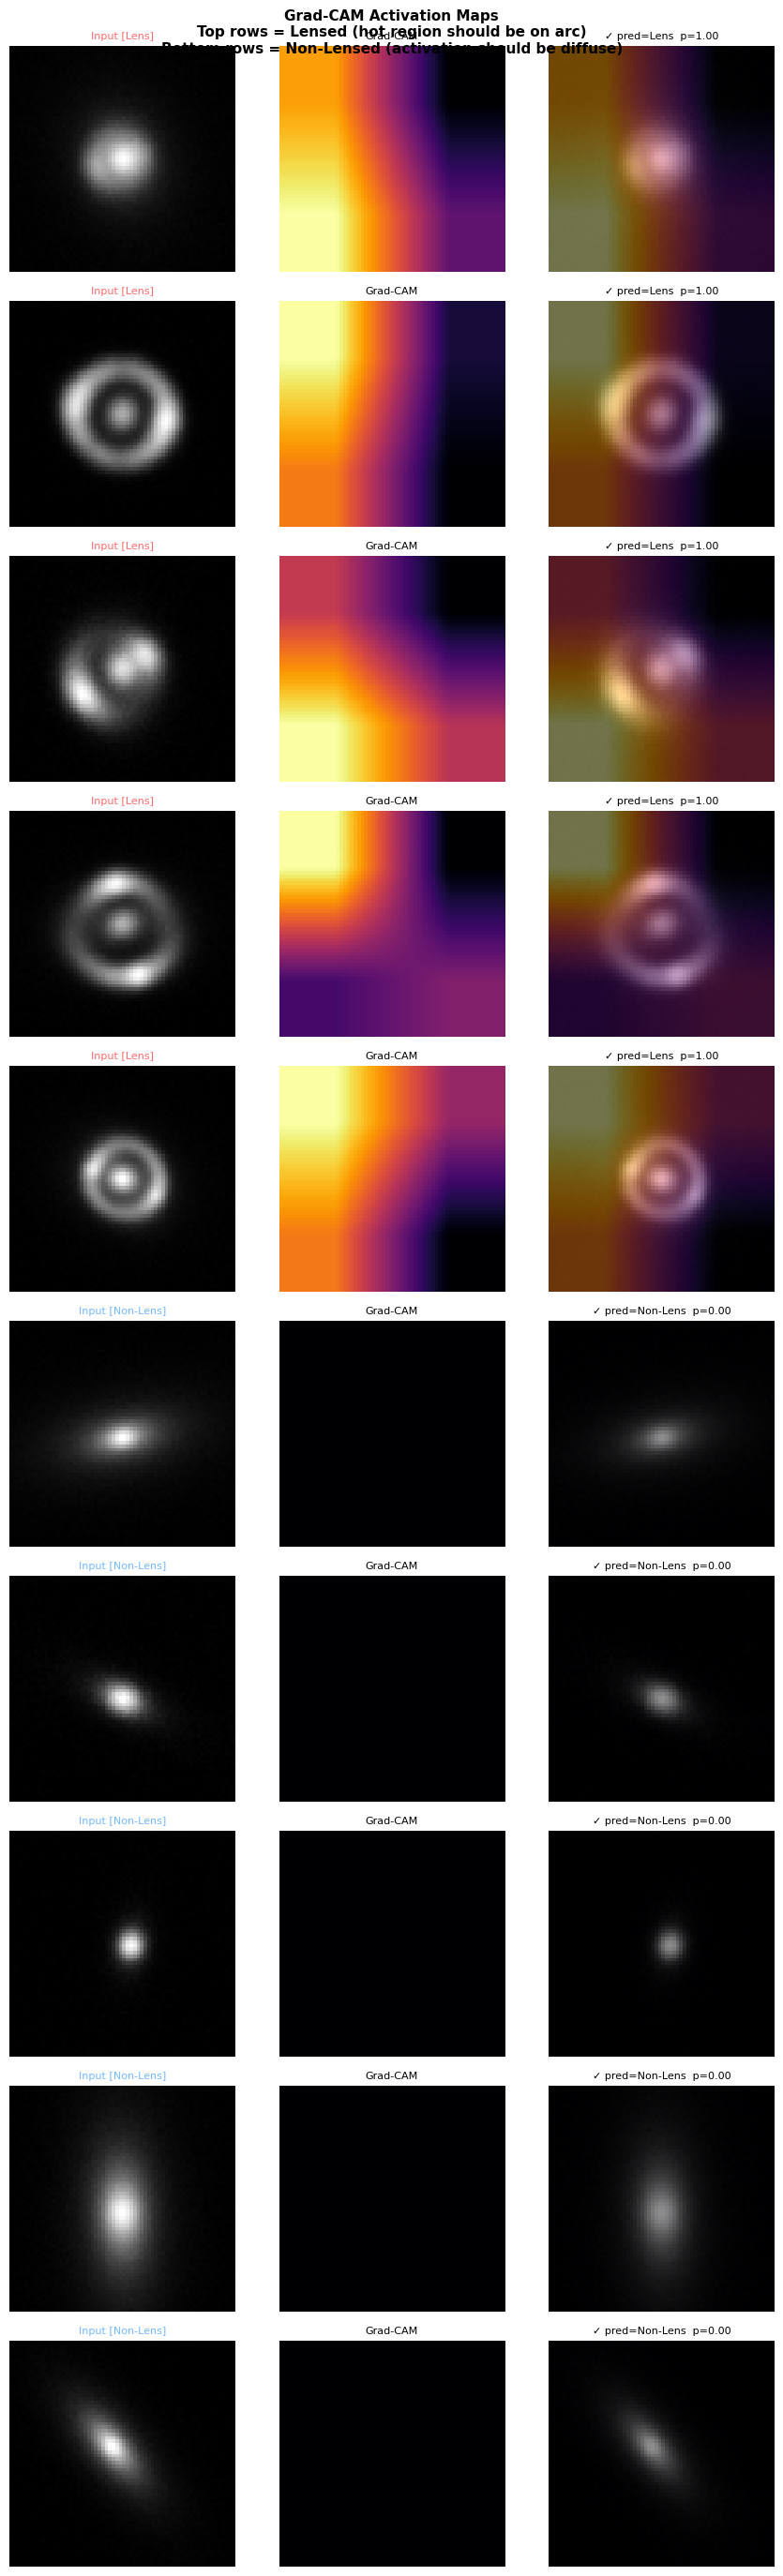

What to look for:
  Lensed     → yellow/hot region concentrated on the arc structure
  Non-lensed → activation spread over galaxy core, no sharp ring
If activations look physically sensible, the model has learned real features.


In [12]:
import torch.nn.functional as F
import torchvision.transforms as T
import config

class GradCAM:
    def __init__(self, mdl, layer):
        self.acts = self.grads = None
        layer.register_forward_hook(lambda m,i,o: setattr(self,'acts',o.detach()))
        layer.register_full_backward_hook(lambda m,gi,go: setattr(self,'grads',go[0].detach()))
        self.mdl = mdl

    def __call__(self, x):
        self.mdl.zero_grad()
        logit = self.mdl(x)
        logit.backward(torch.ones_like(logit))
        w   = self.grads.mean(dim=[2,3], keepdim=True)
        cam = F.relu((w * self.acts).sum(1, keepdim=True))
        cam = F.interpolate(cam, x.shape[2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        return (cam-cam.min())/(cam.max()-cam.min()+1e-8), torch.sigmoid(logit).item()

val_tf  = T.Compose([T.Normalize([0.5]*3, [0.5]*3)])
gcam    = GradCAM(model, model.backbone.layer4[-1].conv2)
N_SHOW  = 5

def preprocess(path):
    raw = np.load(path).astype(np.float32)
    img = np.log1p(np.maximum(raw, 0.))
    lo, hi = img.min(), img.max()
    img = (img - lo)/(hi - lo + 1e-8)
    t   = torch.from_numpy(img).float().unsqueeze(0).repeat(3,1,1)
    return val_tf(t).unsqueeze(0).to(device), raw

# Pick N_SHOW lensed + N_SHOW nonlensed example files
examples = [(f'data/lens_{i:02d}.npy',    1) for i in range(1, N_SHOW+1)] + \
           [(f'data/nonlens_{i:02d}.npy', 0) for i in range(1, N_SHOW+1)]

fig, axes = plt.subplots(N_SHOW*2, 3, figsize=(9, N_SHOW*2*2.8))

for row, (path, true_lbl) in enumerate(examples):
    img_t, raw = preprocess(path)
    with torch.enable_grad():
        cam, prob = gcam(img_t)

    raw_disp = np.clip(img_t[0,0].detach().cpu().numpy()*0.5+0.5, 0, 1)
    label_str = 'Lens' if true_lbl == 1 else 'Non-Lens'
    pred_str  = 'Lens' if prob > 0.5 else 'Non-Lens'
    match     = '✓' if (prob>0.5)==bool(true_lbl) else '✗'
    colour    = '#ff6b6b' if true_lbl==1 else '#74b9ff'

    axes[row,0].imshow(raw_disp, cmap='gray', origin='lower')
    axes[row,0].set_title(f'Input [{label_str}]', color=colour, fontsize=8)
    axes[row,0].axis('off')

    axes[row,1].imshow(cam, cmap='inferno', origin='lower')
    axes[row,1].set_title('Grad-CAM', fontsize=8)
    axes[row,1].axis('off')

    overlay = np.clip(0.55*plt.cm.gray(raw_disp)[...,:3]
                    + 0.45*plt.cm.inferno(cam)[...,:3], 0, 1)
    axes[row,2].imshow(overlay, origin='lower')
    axes[row,2].set_title(f'{match} pred={pred_str}  p={prob:.2f}', fontsize=8)
    axes[row,2].axis('off')

plt.suptitle(
    'Grad-CAM Activation Maps\n'
    'Top rows = Lensed (hot region should be on arc)\n'
    'Bottom rows = Non-Lensed (activation should be diffuse)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(); plt.show()

print("What to look for:")
print("  Lensed     → yellow/hot region concentrated on the arc structure")
print("  Non-lensed → activation spread over galaxy core, no sharp ring")
print("If activations look physically sensible, the model has learned real features.")

---
## Cell 9 — Final summary of all checks

In [13]:
lens_acc    = (all_preds[all_true==1] == 1).mean()
nonlens_acc = (all_preds[all_true==0] == 0).mean()

checks = [
    ("Test AUC-ROC ≥ 0.90",           auc  >= 0.90,  f"{auc:.4f}"),
    ("Test Accuracy ≥ 0.85",          acc  >= 0.85,  f"{acc:.4f}"),
    ("F1 Score ≥ 0.80",               f1   >= 0.80,  f"{f1:.4f}"),
    ("No class collapse (lens acc)",  lens_acc > 0.3, f"{lens_acc:.3f}"),
    ("No class collapse (nonlens)",   nonlens_acc > 0.3, f"{nonlens_acc:.3f}"),
    ("Example files ≥80% correct",    score >= 0.80, f"{correct}/{len(results)}"),
]

print("═" * 52)
print("  FINAL VERIFICATION SUMMARY")
print("═" * 52)
for name, passed, val in checks:
    status = '✓ PASS' if passed else '✗ FAIL'
    print(f"  {status}  {name:<35} {val}")
n_pass = sum(p for _,p,_ in checks)
print("═" * 52)
print(f"  {n_pass}/{len(checks)} checks passed")
print("═" * 52)

════════════════════════════════════════════════════
  FINAL VERIFICATION SUMMARY
════════════════════════════════════════════════════
  ✓ PASS  Test AUC-ROC ≥ 0.90                 1.0000
  ✓ PASS  Test Accuracy ≥ 0.85                1.0000
  ✓ PASS  F1 Score ≥ 0.80                     1.0000
  ✓ PASS  No class collapse (lens acc)        1.000
  ✓ PASS  No class collapse (nonlens)         1.000
  ✓ PASS  Example files ≥80% correct          20/20
════════════════════════════════════════════════════
  6/6 checks passed
════════════════════════════════════════════════════
